# Problem Session 7

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

sns.set_style("whitegrid")

Monthly Average CO2 levels from Mauna Loa are available here: https://gml.noaa.gov/ccgg/trends/

In [2]:
df = pd.read_csv('../../data/co2.csv', usecols = ['year', 'month', 'average'])
df['date'] = pd.to_datetime(df.assign(day=1)[['year', 'month', 'day']])
df.head()

,year,month,average,date
0,1958,3,315.71,1958-03-01
1,1958,4,317.45,1958-04-01
2,1958,5,317.51,1958-05-01
3,1958,6,317.27,1958-06-01
4,1958,7,315.87,1958-07-01


Our goal is to create an accurate forecaster with a time horizon of one year (which is 12 time steps).

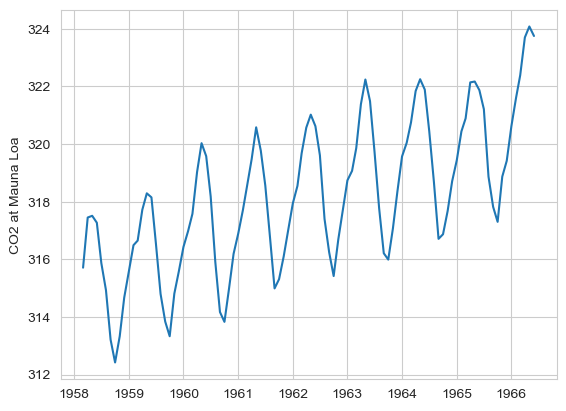

In [3]:
# Visualize the first 100 data points.  How would you describe the trend and seasonality?
plt.plot(df.date.iloc[:100], df.average.iloc[:100])
plt.ylabel('CO2 at Mauna Loa')
plt.show()

The structure of the directory you are working in looks like this:

```
problem session/
├── timeseries_baselines/
│   ├── __init__.py
│   └── baselines.py
└── problem_session.ipynb
```

The `__init__.py` file tells Python to treat the timeseries_baselines directory as a module, allowing you to import from it. The file baselines.py defines three baseline models: `NaiveBaseline`, `RandomWalkWithDrift`, and `NaiveSeasonalWithDrift`. Neither `sklearn` nor `statsmodels` has these baselines implemented so we are going to roll our own. 

Going forward, aim to put most of your implementation code in `.py` files. Use `.ipynb` notebooks primarily for testing, experimentation, and communicating results.

In [4]:
# Modify timeseries_baselines/baselines.py until this cell passes all asserts.
from timeseries_baselines.baselines_solutions import NaiveBaseline, RandomWalkWithDrift, NaiveSeasonalWithDrift

nb_test = NaiveBaseline()
nb_test.fit(np.array([4,5,3,5,1]))
np.testing.assert_array_equal(nb_test.forecast(3), np.array([1,1,1]))

rwwd_test = RandomWalkWithDrift()
rwwd_test.fit(np.array([4,5,3,5,8]))
np.testing.assert_array_equal(rwwd_test.forecast(3), np.array([9,10,11]))

nswd_test = NaiveSeasonalWithDrift(season_length=4)
nswd_test.fit(np.array([4,2,43,4,3,4,5,6,5]))
np.testing.assert_array_equal(nswd_test.forecast(8), np.array([6,7,8,7, 8, 9, 10, 9]))

As a quick visual check, train all 3 baselines on `df.average[:100]` and forecast 24 months.

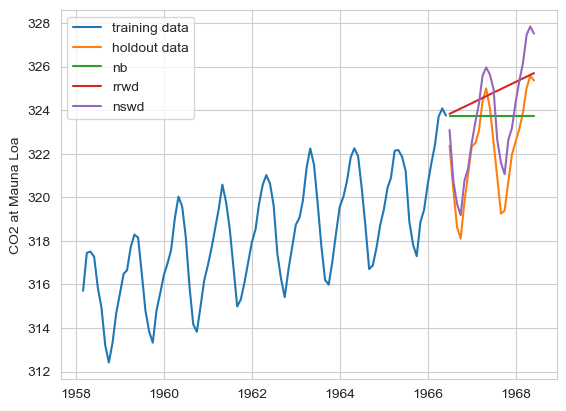

In [5]:
# Fit the models
nb = NaiveBaseline()
nb.fit(df.average[:100])
nb_forecast = nb.forecast(24)

rwwd = RandomWalkWithDrift()
rwwd.fit(df.average[:100])
rwwd_forecast = rwwd.forecast(24)

nswd = NaiveSeasonalWithDrift(season_length=12)
nswd.fit(df.average[:100])
nswd_forecast = nswd.forecast(24)

# Your plotting code here
plt.plot(df.date.iloc[:100], df.average.iloc[:100], label = 'training data')
plt.plot(df.date.iloc[100:124], df.average.iloc[100:124], label = 'holdout data')
plt.plot(df.date.iloc[100:124], nb_forecast, label = 'nb')
plt.plot(df.date.iloc[100:124], rwwd_forecast, label = 'rrwd')
plt.plot(df.date.iloc[100:124], nswd_forecast, label = 'nswd')

plt.ylabel('CO2 at Mauna Loa')
plt.legend()
plt.show()

In [6]:
from statsmodels.tsa.api import ExponentialSmoothing

# Fit a "triple exponential smoothing" model with additive trend and seasonal components.
# Look up the docs for how to do this!
# Train using the first 100 data points.

seasonal_exp_smoothing = ExponentialSmoothing(
    df.average.iloc[:100],
    trend="add",              # additive trend to capture linear slope
    seasonal="add",           # additive seasonality if amplitude is constant
    seasonal_periods=12,      # for monthly data with yearly seasonality
    initialization_method="estimated"  # more stable than "heuristic"
).fit()
es_forecast = seasonal_exp_smoothing.forecast(steps=24)

Plot the following on one graph:
* training data (first 100 observations)
* holdout data (next 24 observations)
* exponential smoothing forecast
* seasonal naive with drift forecast

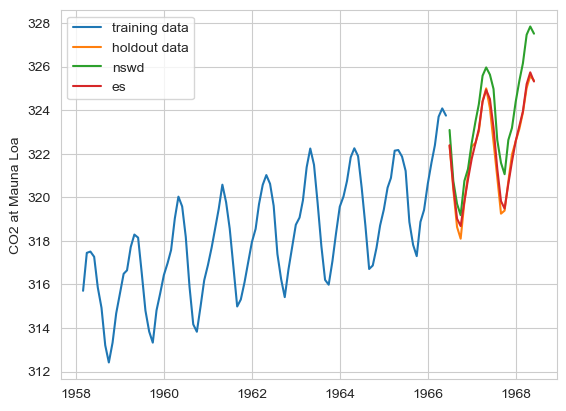

In [7]:
# Your plotting code here
plt.plot(df.date.iloc[:100], df.average.iloc[:100], label = 'training data')
plt.plot(df.date.iloc[100:124], df.average.iloc[100:124], label = 'holdout data')
plt.plot(df.date.iloc[100:124], nswd_forecast, label = 'nswd')
plt.plot(df.date.iloc[100:124], es_forecast, label = 'es')


plt.ylabel('CO2 at Mauna Loa')
plt.legend()
plt.show()

It looks from this initial experimentation that the exponential smoothing model is going to be the best.  Let's use time series cross validation to evaluate the forecasting error of each model.

In [8]:
from sklearn.metrics import mean_squared_error as mse
from sklearn.model_selection import TimeSeriesSplit

In [9]:
season_length = 12
df_train = df.iloc[:-season_length*5]

# Note:  it doesn't really make sense to make a df_test using the remainder of 
# the data.  You want the full history when evaluating on the test set.  So 
# when you do eventually do a test of the final model you will use another time series split 
# on the original df.

n_splits = 10
kfold = TimeSeriesSplit(n_splits = n_splits,
                           test_size = season_length)

nb_mses = np.zeros(n_splits)
rrwd_mses = np.zeros(n_splits)
nswd_mses = np.zeros(n_splits)
es_mses = np.zeros(n_splits)

for i, (train_index, test_index) in enumerate(kfold.split(df_train)):
    ts_tt = df.average.iloc[train_index]
    ts_ho = df.average.iloc[test_index]
    
    nb = NaiveBaseline()
    nb.fit(ts = ts_tt)
    nb_preds = nb.forecast(season_length)
    nb_mses[i] = mse(ts_ho, nb_preds)

    rrwd = RandomWalkWithDrift()
    rrwd.fit(ts_tt)
    rrwd_preds = rrwd.forecast(season_length)
    rrwd_mses[i] = mse(ts_ho, rrwd_preds)

    nswd = NaiveSeasonalWithDrift(season_length=12)
    nswd.fit(ts_tt)
    nswd_preds = nswd.forecast(season_length)
    nswd_mses[i] = mse(ts_ho, nswd_preds)

    es = ExponentialSmoothing(
            ts_tt,
            trend="add",              # additive trend to capture linear slope
            seasonal="add",           # additive seasonality if amplitude is constant
            seasonal_periods=12,      # for monthly data with yearly seasonality
            initialization_method="estimated"  # more stable than "heuristic"
        ).fit()
    es_preds = es.forecast(season_length)
    es_mses[i] = mse(ts_ho, es_preds)

cv_mse = {'nb':nb_mses, 'rrwd':rrwd_mses, 'nswd':nswd_mses, 'es': es_mses}

In [10]:
cv_averages = {name: a.mean() for name, a in cv_mse.items()}
cv_averages

{'nb': np.float64(8.161591666666698),
 'rrwd': np.float64(10.785412436177776),
 'nswd': np.float64(0.9194541666666801),
 'es': np.float64(0.3135617749779072)}

Now evaluate the model which performed best in cross-validation on the test set.  You should use another time series split for this!  Do you see evidence that the model was under or overfitting?

In [11]:
n_splits = 5
kfold = TimeSeriesSplit(n_splits = n_splits,
                           test_size = season_length)

es_mses = np.zeros(n_splits)

for i, (train_index, test_index) in enumerate(kfold.split(df)):
    ts_tt = df.average.iloc[train_index]
    ts_ho = df.average.iloc[test_index]
    
    es = ExponentialSmoothing(
            ts_tt,
            trend="add",              # additive trend to capture linear slope
            seasonal="add",           # additive seasonality if amplitude is constant
            seasonal_periods=12,      # for monthly data with yearly seasonality
            initialization_method="estimated"  # more stable than "heuristic"
        ).fit()
    es_preds = es.forecast(season_length)
    es_mses[i] = mse(ts_ho, es_preds)

es_mses.mean()

np.float64(0.37019482667770776)